# Test Metrics and UMAP Analysis

This notebook tests the AnnData creation, NPMI-based purity/conflict metrics, and UMAP visualization for lung cancer transcript data across different cell ID versions:
- Original segmentation
- Stitched segmentation (whole cells and partial/pseudocells)
- Fine-tuned segmentation (whole cells and partial/pseudocells)

## 1. Setup and Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Add the hotnerd package to the path
sys.path.insert(0, "../../src")

from hotnerd.plot import make_adata, is_whole_cell_id, is_partial_or_pseudocell_id
from hotnerd.metrics import (
    compute_npmi,
    build_cell_gene_matrix,
    build_npmi_matrix,
    compute_cell_purity,
    compute_cell_conflict,
    compute_purity_and_conflict,
    attach_metrics_to_adata,
)

# Set up plotting
sc.set_figure_params(dpi=100, frameon=False)
sns.set_style("whitegrid")

print("✓ Imports successful")

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful


In [20]:
# Reload the hotnerd modules to get latest changes
import importlib
import hotnerd.metrics
import hotnerd.plot

importlib.reload(hotnerd.metrics)
importlib.reload(hotnerd.plot)

# Re-import functions after reload
from hotnerd.metrics import (
    compute_npmi,
    build_cell_gene_matrix,
    build_npmi_matrix,
    compute_cell_purity,
    compute_cell_conflict,
    compute_purity_and_conflict,
    attach_metrics_to_adata,
)

print("✓ Modules reloaded and functions re-imported")

✓ Modules reloaded and functions re-imported


## 2. Load Transcript Data

In [105]:
# Load transcript data
df = pd.read_parquet("output/df_finetuned.parquet")

print(f"Loaded {len(df):,} transcripts")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Loaded 1,436,900 transcripts
Columns: ['x', 'y', 'z', 'feature_name', 'cell_id', 'nucleus_distance', 'transcript_id', 'fov_name', 'qv', 'overlaps_nucleus', 'cell_id_npmi_cons_p1', 'npmi_cons_p1_status', 'cell_id_npmi_cons_p2', 'npmi_cons_p2_status', 'unassigned_comp_id', 'unassigned_qc_status', 'unassigned_comp_size', 'cell_id_final', 'cell_id_stitched', 'cell_id_spatial', 'cell_id_finetuned']

First few rows:


,x,y,z,feature_name,cell_id,nucleus_distance,transcript_id,fov_name,qv,overlaps_nucleus,...,npmi_cons_p1_status,cell_id_npmi_cons_p2,npmi_cons_p2_status,unassigned_comp_id,unassigned_qc_status,unassigned_comp_size,cell_id_final,cell_id_stitched,cell_id_spatial,cell_id_finetuned
0,90.116203,1481.733154,11.636851,MZB1,-1,141.229370,281509336450057,D6,40.000000,0,...,unassigned_input,-1,unchanged,UNASSIGNED_0,drop_small_comp,1.0,DROP,DROP,DROP,DROP
1,148.954025,1657.631226,11.568077,VAMP8,-1,140.643250,281509336449024,D6,40.000000,0,...,unassigned_input,-1,unchanged,UNASSIGNED_1,drop_small_comp,1.0,DROP,DROP,DROP,DROP
2,138.317154,1597.401001,11.680394,RORC,-1,102.513069,281509336449738,D6,40.000000,0,...,unassigned_input,-1,unchanged,UNASSIGNED_2,drop_small_comp,1.0,DROP,DROP,DROP,DROP
3,162.937073,1656.976318,11.793150,RORC,-1,133.364517,281509336449739,D6,40.000000,0,...,unassigned_input,-1,unchanged,UNASSIGNED_3,drop_small_comp,1.0,DROP,DROP,DROP,DROP
4,56.945526,1596.405273,11.688915,HEPACAM2,-1,174.493057,281509336449800,D6,39.681641,0,...,unassigned_input,-1,unchanged,UNASSIGNED_4,drop_small_comp,1.0,DROP,DROP,DROP,DROP


## 3. Create AnnData Objects for Different Cell ID Versions

In [106]:
# Create AnnData for original cell_id
adata_orig = make_adata(
    df,
    cell_col="cell_id",
    gene_col="feature_name",
    name="Original cell_id",
    exclude_ids={"-1"},
)

print(f"✓ adata_orig: {adata_orig.shape[0]} cells × {adata_orig.shape[1]} genes")
print(f"  Mean transcripts/cell: {adata_orig.obs['n_transcripts'].mean():.1f}")
print(f"  Mean genes/cell: {adata_orig.obs['n_genes'].mean():.1f}")

✓ adata_orig: 58405 cells × 300 genes
  Mean transcripts/cell: 24.6
  Mean genes/cell: 13.6


In [107]:
# Stitched segmentation
stitched = df["cell_id_stitched"].astype(str)

# Stitched whole cells
df_st_whole = df[is_whole_cell_id(stitched)].copy()
adata_st_whole = make_adata(
    df_st_whole,
    cell_col="cell_id_stitched",
    gene_col="feature_name",
    name="Stitched whole",
    exclude_ids={"-1", "DROP", "nan"},
)

print(f"✓ adata_st_whole: {adata_st_whole.shape[0]} cells × {adata_st_whole.shape[1]} genes")
print(f"  Mean transcripts/cell: {adata_st_whole.obs['n_transcripts'].mean():.1f}")
print(f"  Mean genes/cell: {adata_st_whole.obs['n_genes'].mean():.1f}")

# Stitched partial + pseudocells
df_st_frag = df[is_partial_or_pseudocell_id(stitched)].copy()
adata_st_frag = make_adata(
    df_st_frag,
    cell_col="cell_id_stitched",
    gene_col="feature_name",
    name="Stitched partial+pseudocell",
    exclude_ids={"-1", "DROP", "nan"},
)

print(f"✓ adata_st_frag: {adata_st_frag.shape[0]} cells × {adata_st_frag.shape[1]} genes")
print(f"  Mean transcripts/cell: {adata_st_frag.obs['n_transcripts'].mean():.1f}")
print(f"  Mean genes/cell: {adata_st_frag.obs['n_genes'].mean():.1f}")

✓ adata_st_whole: 58405 cells × 300 genes
  Mean transcripts/cell: 20.0
  Mean genes/cell: 11.1
✓ adata_st_frag: 11330 cells × 93 genes
  Mean transcripts/cell: 9.3
  Mean genes/cell: 4.2


In [108]:
# Fine-tuned segmentation
finetuned = df["cell_id_finetuned"].astype(str)

# Fine-tuned whole cells
df_ft_whole = df[is_whole_cell_id(finetuned)].copy()
adata_ft_whole = make_adata(
    df_ft_whole,
    cell_col="cell_id_finetuned",
    gene_col="feature_name",
    name="Fine-tuned whole",
    exclude_ids={"-1", "DROP", "nan"},
)

print(f"✓ adata_ft_whole: {adata_ft_whole.shape[0]} cells × {adata_ft_whole.shape[1]} genes")
print(f"  Mean transcripts/cell: {adata_ft_whole.obs['n_transcripts'].mean():.1f}")
print(f"  Mean genes/cell: {adata_ft_whole.obs['n_genes'].mean():.1f}")

# Fine-tuned partial + pseudocells
df_ft_frag = df[is_partial_or_pseudocell_id(finetuned)].copy()
adata_ft_frag = make_adata(
    df_ft_frag,
    cell_col="cell_id_finetuned",
    gene_col="feature_name",
    name="Fine-tuned partial+pseudocell",
    exclude_ids={"-1", "DROP", "nan"},
)

print(f"✓ adata_ft_frag: {adata_ft_frag.shape[0]} cells × {adata_ft_frag.shape[1]} genes")
print(f"  Mean transcripts/cell: {adata_ft_frag.obs['n_transcripts'].mean():.1f}")
print(f"  Mean genes/cell: {adata_ft_frag.obs['n_genes'].mean():.1f}")

✓ adata_ft_whole: 58405 cells × 300 genes
  Mean transcripts/cell: 18.7
  Mean genes/cell: 10.3
✓ adata_ft_frag: 27148 cells × 296 genes
  Mean transcripts/cell: 6.7
  Mean genes/cell: 4.1


## 4. Load NPMI Data

Load pre-computed nucleus-level NPMI (or compute it if not available)

In [6]:
# Load NPMI data
nucleus_npmi_long = pd.read_csv("data/lung_cancer_npmi.csv")

print(f"✓ Loaded NPMI data: {len(nucleus_npmi_long):,} gene pairs")
print(f"  Unique genes: {len(set(nucleus_npmi_long['gene_i']) | set(nucleus_npmi_long['gene_j']))}")
print(f"  NPMI range: [{nucleus_npmi_long['NPMI'].min():.3f}, {nucleus_npmi_long['NPMI'].max():.3f}]")
print(f"\nFirst few rows:")
nucleus_npmi_long.head()

✓ Loaded NPMI data: 44,100 gene pairs
  Unique genes: 210
  NPMI range: [-0.400, 1.000]

First few rows:


,gene_i,gene_j,P_i,P_j,P_ij,P_i_given_j,P_j_given_i,PMI,NPMI
0,ACE,ACE,0.000556,0.000556,0.000556,1.000000,1.0000,7.495507,1.000000
1,ACE,ACTA2,0.000556,0.019549,0.000035,0.001776,0.0625,1.162228,0.113188
2,ACE,ADGRL4,0.000556,0.000278,0.000000,0.000000,0.0000,NaN,NaN
3,ACE,AK1,0.000556,0.000278,0.000000,0.000000,0.0000,NaN,NaN
4,ACE,AKR1C1,0.000556,0.001389,0.000000,0.000000,0.0000,NaN,NaN


## 5. Tutorial on How to Use Individual Functions First

Before using the integrated function, test the individual components to understand the workflow and debug issues.

In [7]:
# Test with stitched whole cells dataset
print("Testing with df_st_whole...")

# Step 1: Build cell-gene matrix
cell_ids, genes_cell, M, col_idx = build_cell_gene_matrix(
    df_st_whole,
    min_transcripts=3,
    genes_npm=nucleus_npmi_long,
)

print(f"✓ Cell-gene matrix: {M.shape[0]} cells × {M.shape[1]} genes")
print(f"  Sparsity: {(M == 0).sum() / M.size * 100:.1f}%")
print(f"  Mean genes per cell: {M.sum(axis=1).mean():.1f}")

Testing with df_st_whole...
✓ Cell-gene matrix: 56738 cells × 210 genes
  Sparsity: 93.6%
  Mean genes per cell: 13.4


In [8]:
# Step 2: Build NPMI matrix
npmi_mat, gene_to_idx_all = build_npmi_matrix(nucleus_npmi_long)

print(f"✓ NPMI matrix: {npmi_mat.shape[0]} × {npmi_mat.shape[1]}")
print(f"  Nonzero entries: {(npmi_mat != 0).sum()}")
print(f"  Value range: [{npmi_mat.min():.3f}, {npmi_mat.max():.3f}]")

✓ NPMI matrix: 210 × 210
  Nonzero entries: 44100
  Value range: [nan, nan]


In [9]:
# Step 3: Compute purity scores
purity_scores, is_pure, purity_thr, purity_df = compute_cell_purity(
    M=M,
    col_idx=col_idx,
    npmi_mat=npmi_mat,
    npmi_threshold=0.05,
    cell_ids=cell_ids,
    purity_percentile=80.0,
)

print(f"✓ Purity scores computed")
print(f"  Purity threshold: {purity_thr:.3f}")
print(f"  Valid scores: {(~np.isnan(purity_scores)).sum()} / {len(purity_scores)}")
print(f"  Pure cells: {is_pure.sum()} ({is_pure.sum()/len(is_pure)*100:.1f}%)")
print(f"  Purity range: [{np.nanmin(purity_scores):.3f}, {np.nanmax(purity_scores):.3f}]")
print(f"\nPurity DataFrame:")
purity_df.head()

✓ Purity scores computed
  Purity threshold: 0.363
  Valid scores: 56704 / 56738
  Pure cells: 11348 (20.0%)
  Purity range: [0.000, 1.000]

Purity DataFrame:


,cell_id,cell_purity,is_pure
0,1,0.263736,False
1,10,0.136364,False
2,100,0.290909,False
3,1000,0.200000,False
4,10000,0.161905,False


In [10]:
# Step 4: Compute conflict scores
conflict_scores, is_conflict, conflict_thr, conflict_df = compute_cell_conflict(
    M=M,
    col_idx=col_idx,
    npmi_mat=npmi_mat,
    cell_ids=cell_ids,
    conflict_percentile=80.0,
)

print(f"✓ Conflict scores computed")
print(f"  Conflict threshold: {conflict_thr:.3f}")
print(f"  Valid scores: {(~np.isnan(conflict_scores)).sum()} / {len(conflict_scores)}")
print(f"  Conflicting cells: {is_conflict.sum()} ({is_conflict.sum()/len(is_conflict)*100:.1f}%)")
print(f"  Conflict range: [{np.nanmin(conflict_scores):.3f}, {np.nanmax(conflict_scores):.3f}]")
print(f"\nConflict DataFrame:")
conflict_df.head()

✓ Conflict scores computed
  Conflict threshold: 0.042
  Valid scores: 56704 / 56738
  Conflicting cells: 11341 (20.0%)
  Conflict range: [0.000, 0.400]

Conflict DataFrame:


,cell_id,conflict_score,is_conflict
0,1,0.048270,True
1,10,0.017505,False
2,100,0.029967,False
3,1000,0.031739,False
4,10000,0.008261,False


## 6. Or You Can Use the Integrated compute_purity_and_conflict Function

Now test the full integrated function.

In [110]:
# Test with stitched whole cells
print("=" * 60)
print("Testing compute_purity_and_conflict with stitched whole cells")
print("=" * 60)

try:
    purity_df_st, conflict_df_st = compute_purity_and_conflict(
        filtered_df=df_st_whole,
        nucleus_npmi_long=nucleus_npmi_long,
        adata=adata_st_whole,
        cell_col="cell_id_stitched",  
        min_transcripts_per_cell=3,
        npmi_threshold=0.05,
        purity_percentile=80.0,
        conflict_percentile=80.0,
        exclude_ids={"-1", "DROP", "nan"},
    )
    
    print("\n✓ Success!")
    print(f"Purity DF shape: {purity_df_st.shape}")
    print(f"Conflict DF shape: {conflict_df_st.shape}")
    
    # Check if metrics were added to adata
    print(f"\nMetrics in adata_st_whole.obs:")
    print(adata_st_whole.obs[['n_transcripts', 'n_genes', 'cell_purity', 
                               'cell_purity_bool', 'conflict_score', 'is_conflict']].head())
    
except Exception as e:
    print(f"\n✗ Error: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Testing compute_purity_and_conflict with stitched whole cells
Purity threshold used: 0.4727272727272727
Conflict threshold used: 0.012441535440400785

✓ Success!
Purity DF shape: (57608, 3)
Conflict DF shape: (57608, 3)

Metrics in adata_st_whole.obs:
       n_transcripts  n_genes  cell_purity cell_purity_bool  conflict_score  \
1                 20        9     0.416667            False        0.007302   
10                10        9     0.055556            False        0.000000   
100               12        9     0.388889            False        0.003953   
1000               5        5     0.300000            False        0.005388   
10000             15       13     0.153846            False        0.002199   

      is_conflict  
1           False  
10          False  
100         False  
1000        False  
10000       False  


## 7. Compute Metrics for All AnnData Objects

In [111]:
# Compute metrics for stitched partial/pseudocells
print("\n" + "=" * 60)
print("Computing metrics for stitched partial+pseudocells")
print("=" * 60)

try:
    purity_df_st_frag, conflict_df_st_frag = compute_purity_and_conflict(
        filtered_df=df_st_frag,
        nucleus_npmi_long=nucleus_npmi_long,
        adata=adata_st_frag,
        cell_col="cell_id_stitched",
        min_transcripts_per_cell=3,
        npmi_threshold=0.05,
        purity_percentile=80.0,
        conflict_percentile=80.0,
        exclude_ids={"-1", "DROP", "nan"},
    )
    print("✓ adata_st_frag: Success")
except Exception as e:
    print(f"✗ adata_st_frag: {type(e).__name__}: {e}")


Computing metrics for stitched partial+pseudocells
Purity threshold used: 1.0
Conflict threshold used: 0.01597177392800142
✓ adata_st_frag: Success


In [112]:
# Compute metrics for fine-tuned whole cells
print("\n" + "=" * 60)
print("Computing metrics for fine-tuned whole cells")
print("=" * 60)

try:
    purity_df_ft, conflict_df_ft = compute_purity_and_conflict(
        filtered_df=df_ft_whole,
        nucleus_npmi_long=nucleus_npmi_long,
        adata=adata_ft_whole,
        cell_col="cell_id_finetuned",
        min_transcripts_per_cell=3,
        npmi_threshold=0.05,
        purity_percentile=80.0,
        conflict_percentile=80.0,
        exclude_ids={"-1", "DROP", "nan"},
    )
    print("✓ adata_ft_whole: Success")
except Exception as e:
    print(f"✗ adata_ft_whole: {type(e).__name__}: {e}")


Computing metrics for fine-tuned whole cells
Purity threshold used: 0.5
Conflict threshold used: 0.012493850461480563
✓ adata_ft_whole: Success


In [113]:
# Compute metrics for fine-tuned partial/pseudocells
print("\n" + "=" * 60)
print("Computing metrics for fine-tuned partial+pseudocells")
print("=" * 60)

try:
    purity_df_ft_frag, conflict_df_ft_frag = compute_purity_and_conflict(
        filtered_df=df_ft_frag,
        nucleus_npmi_long=nucleus_npmi_long,
        adata=adata_ft_frag,
        cell_col="cell_id_finetuned",
        min_transcripts_per_cell=3,
        npmi_threshold=0.05,
        purity_percentile=80.0,
        conflict_percentile=80.0,
        exclude_ids={"-1", "DROP", "nan"},
    )
    print("✓ adata_ft_frag: Success")
except Exception as e:
    print(f"✗ adata_ft_frag: {type(e).__name__}: {e}")


Computing metrics for fine-tuned partial+pseudocells
Purity threshold used: 1.0
Conflict threshold used: 0.008791134619430386
✓ adata_ft_frag: Success


In [114]:
# Compute metrics for original whole cells
print("\n" + "=" * 60)
print("Computing metrics for multimodal Xenium whole cells")
print("=" * 60)

try:
    purity_df, conflict_df = compute_purity_and_conflict(
        filtered_df=df,
        nucleus_npmi_long=nucleus_npmi_long,
        adata=adata_orig,
        cell_col="cell_id",
        min_transcripts_per_cell=3,
        npmi_threshold=0.05,
        purity_percentile=80.0,
        conflict_percentile=80.0,
        exclude_ids={"-1", "DROP", "nan"},
    )
    print("✓ adata_ft_frag: Success")
except Exception as e:
    print(f"✗ adata_ft_frag: {type(e).__name__}: {e}")


Computing metrics for multimodal Xenium whole cells
Purity threshold used: 0.35833333333333334
Conflict threshold used: 0.04595336655552834
✓ adata_ft_frag: Success


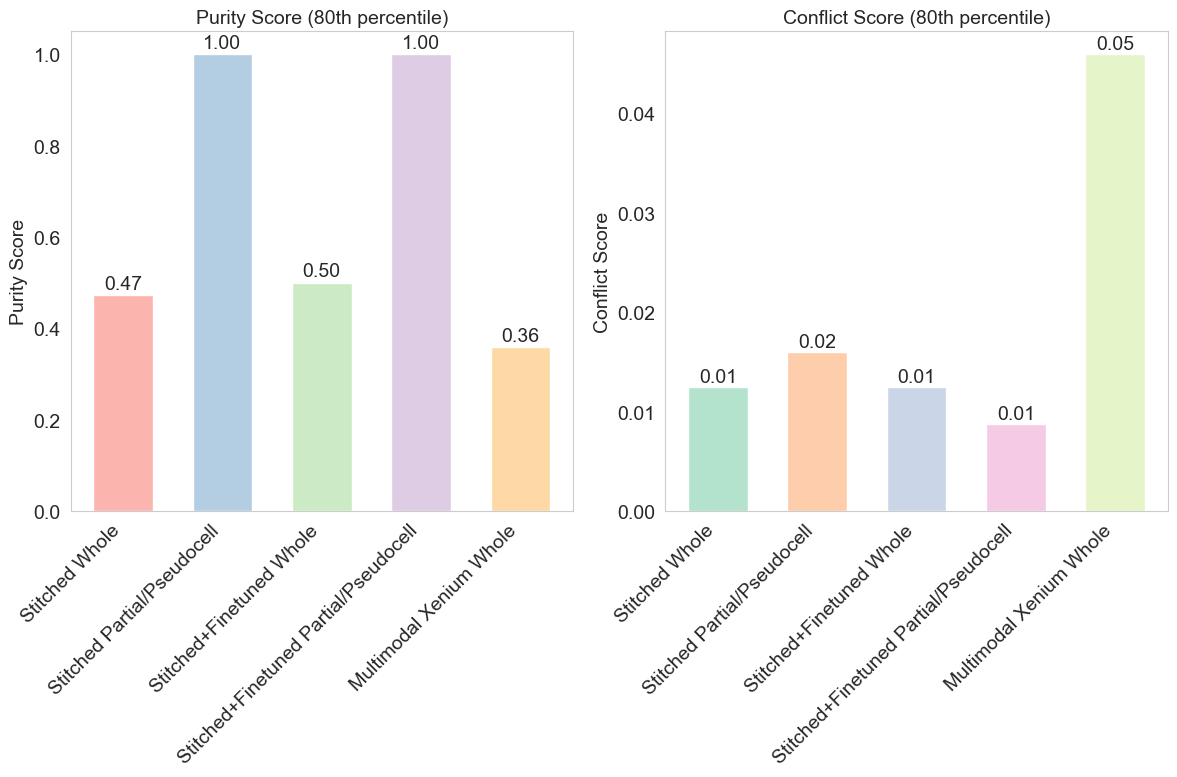

In [115]:
purity_scores = [
    np.nanpercentile(purity_df_st['cell_purity'], 80),
    np.nanpercentile(purity_df_st_frag['cell_purity'], 80),
    np.nanpercentile(purity_df_ft['cell_purity'], 80),
    np.nanpercentile(purity_df_ft_frag['cell_purity'], 80),
    np.nanpercentile(purity_df['cell_purity'], 80)
]

conflict_scores = [
    np.nanpercentile(conflict_df_st['conflict_score'], 80),
    np.nanpercentile(conflict_df_st_frag['conflict_score'], 80),
    np.nanpercentile(conflict_df_ft['conflict_score'], 80),
    np.nanpercentile(conflict_df_ft_frag['conflict_score'], 80),
    np.nanpercentile(conflict_df['conflict_score'], 80)
]

# Labels for x-axis
labels = [
    "Stitched Whole",
    "Stitched Partial/Pseudocell",
    "Stitched+Finetuned Whole",
    "Stitched+Finetuned Partial/Pseudocell",
    "Multimodal Xenium Whole"
]

x = np.arange(len(labels))  # the label locations
width = 0.6  # width of the bars

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# ---------------- PURITY ----------------
bars_purity = axes[0].bar(x, purity_scores, width, color=plt.get_cmap("Pastel1").colors[:len(labels)])
axes[0].grid(False) 
axes[0].set_title("Purity Score (80th percentile)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel("Purity Score")
for bar in bars_purity:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.2f}', ha='center', va='bottom')

# ---------------- CONFLICT ----------------
bars_conflict = axes[1].bar(x, conflict_scores, width, color=plt.get_cmap("Pastel2").colors[:len(labels)])
axes[1].grid(False) 
axes[1].set_title("Conflict Score (80th percentile)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel("Conflict Score")
for bar in bars_conflict:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.0001, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout() 
plt.savefig("plot/lung_cancer_purity_conflict_scores.png", dpi=300) 
plt.show()

## 8. Run UMAP Analysis

Perform standard single-cell preprocessing and UMAP dimensionality reduction.

In [46]:
def run_umap_pipeline(
    adata: sc.AnnData,
    n_pcs=300,
    n_neighbors=15,
    leiden_res=1.0,
    key_prefix="m1",
    name=""
):
    """Run standard scanpy preprocessing and UMAP"""
    print(f"\nProcessing {name}...")

    # Keep raw counts
    adata.layers["counts"] = adata.X.copy()

    # Normalize
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)

    n_pcs_use = min(n_pcs, adata.n_vars - 1, 50_000)  # safety cap if huge vars
    sc.pp.pca(adata, n_comps=n_pcs_use)

    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=min(n_pcs_use, adata.obsm["X_pca"].shape[1]),
    )

    sc.tl.umap(adata)

    # Define the key once, consistently
    leiden_key = f"{key_prefix}_leiden" if not str(key_prefix).endswith("_") else f"{key_prefix}leiden"
    sc.tl.leiden(adata, 
                 resolution=leiden_res, 
                 key_added=leiden_key,
                 flavor="igraph",
                 n_iterations=2,
                 directed=False  # required for igraph
                )

    # store key for downstream metrics
    adata.uns["leiden_key"] = leiden_key
    print(f"  ✓ UMAP complete: {adata.obsm['X_umap'].shape}")
    return adata

In [116]:
# Run UMAP on stitched whole cells (with metrics)
adata_st_whole_umap = run_umap_pipeline(adata_st_whole.copy(), 
                                        n_pcs=300,
                                        n_neighbors=30,
                                        leiden_res=1.0,
                                        key_prefix="",
                                        name="Stitched whole cells")


Processing Stitched whole cells...
  ✓ UMAP complete: (58405, 2)


In [117]:
# Run UMAP on other datasets
adata_st_frag_umap = run_umap_pipeline(adata_st_frag.copy(), 
                                       n_pcs=300,
                                       n_neighbors=100,
                                       leiden_res=0.3,
                                       key_prefix="",
                                       name="Stitched partial+pseudocells")
adata_ft_whole_umap = run_umap_pipeline(adata_ft_whole.copy(), 
                                        n_pcs=300,
                                        n_neighbors=30,
                                        leiden_res=1.0,
                                        key_prefix="",
                                        name="Fine-tuned whole cells")
adata_ft_frag_umap = run_umap_pipeline(adata_ft_frag.copy(), 
                                       n_pcs=300,
                                       n_neighbors=100,
                                       leiden_res=0.3,
                                       key_prefix="",
                                       name="Fine-tuned partial+pseudocells")
adata_orig_umap = run_umap_pipeline(adata_orig.copy(), 
                                    n_pcs=300,
                                    n_neighbors=30,
                                    leiden_res=1.0,
                                    key_prefix="",
                                    name="Original whole cells")


Processing Stitched partial+pseudocells...
  ✓ UMAP complete: (11330, 2)

Processing Fine-tuned whole cells...
  ✓ UMAP complete: (58405, 2)

Processing Fine-tuned partial+pseudocells...
  ✓ UMAP complete: (27148, 2)

Processing Original whole cells...
  ✓ UMAP complete: (58405, 2)


## 9. Visualize Purity and Conflict Scores on UMAP

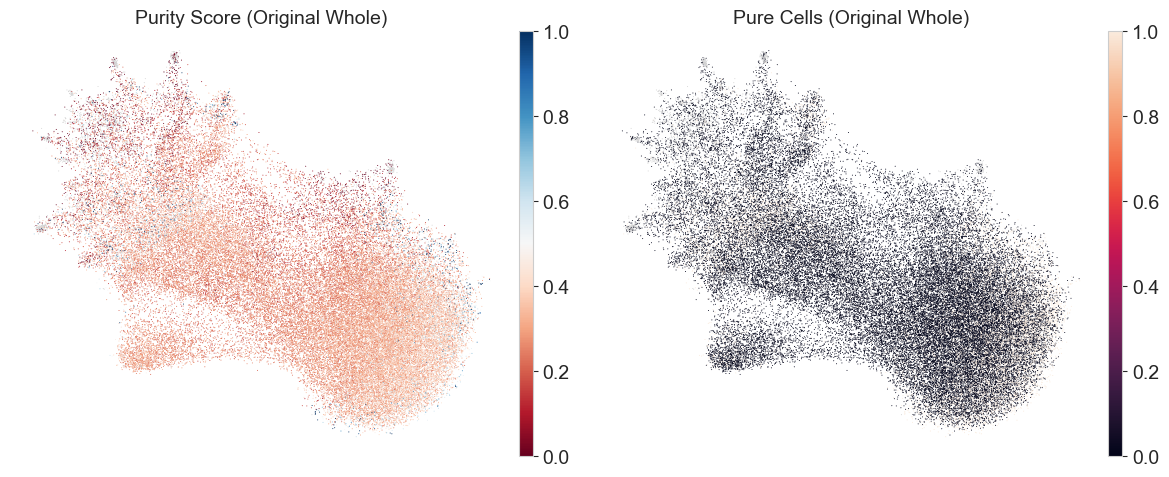

In [118]:
# Visualize purity scores on UMAP (original whole cells)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(adata_orig_umap, color='cell_purity', cmap='RdBu', 
           title='Purity Score (Original Whole)', ax=axes[0], show=False)
sc.pl.umap(adata_orig_umap, color='cell_purity_bool',  
           title='Pure Cells (Original Whole)', ax=axes[1], show=False)

plt.tight_layout()
plt.savefig("plot/lung_cancer_purity_umap.png", dpi=300) 
plt.show()

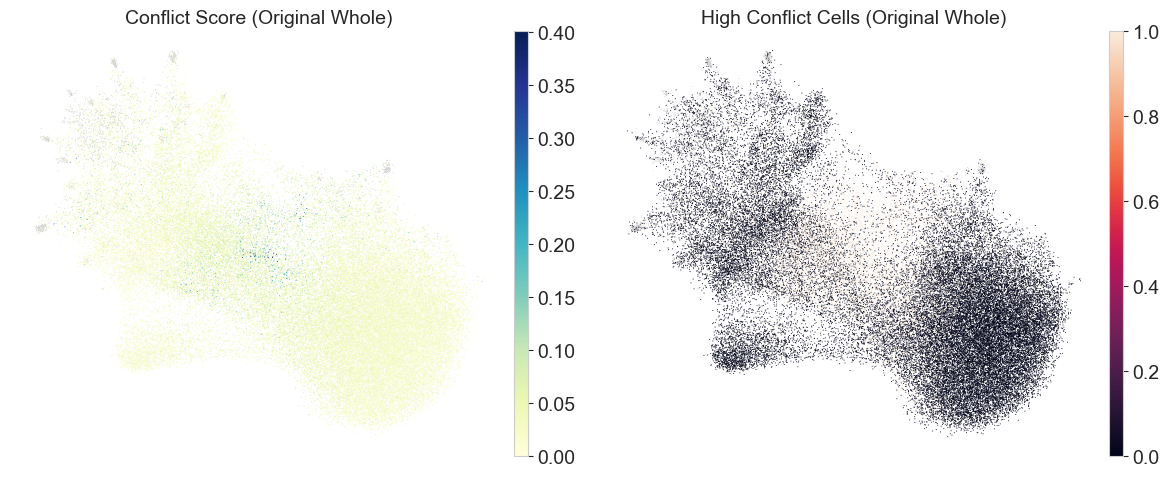

In [119]:
# Visualize conflict scores on UMAP
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(adata_orig_umap, color='conflict_score', cmap='YlGnBu', 
           title='Conflict Score (Original Whole)', ax=axes[0], show=False)
sc.pl.umap(adata_orig_umap, color='is_conflict', 
           title='High Conflict Cells (Original Whole)', ax=axes[1], show=False)

plt.tight_layout()
plt.savefig("plot/lung_cancer_conflict_umap.png", dpi=300) 
plt.show()

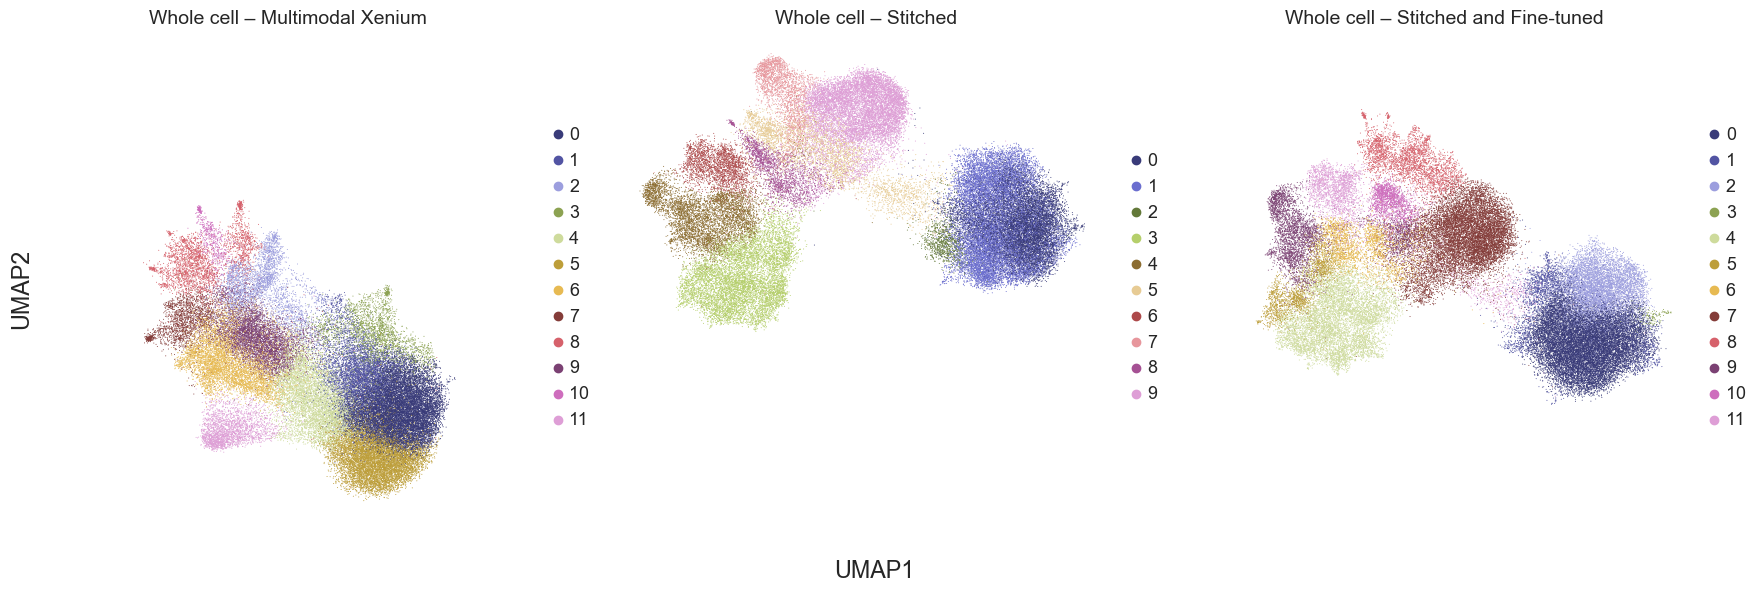

In [120]:
# Whole cell UMAP configurations
whole_configs = [
    (adata_orig_umap, "_leiden", "Whole cell – Multimodal Xenium"),
    (adata_st_whole_umap, "_leiden", "Whole cell – Stitched"),
    (adata_ft_whole_umap, "_leiden", "Whole cell – Stitched and Fine-tuned"),
]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Function to remove axes ticks and spines
def clean_umap_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

# Loop through each UMAP and plot on the corresponding axis
for ax, (adata, leiden_col, title) in zip(axes, whole_configs):
    # Ensure the color key exists
    if leiden_col not in adata.obs.columns:
        raise ValueError(f"{leiden_col} not found in adata.obs")
    
    sc.pl.umap(
        adata,
        color=leiden_col,
        palette="tab20b",
        ax=ax,
        show=False,
        title=title,
    )
    clean_umap_axes(ax)

# Add common axis labels
fig.supxlabel("UMAP1")
fig.supylabel("UMAP2")

plt.tight_layout()
plt.savefig(
    "plot/lung_cancer_umap_whole_cell.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


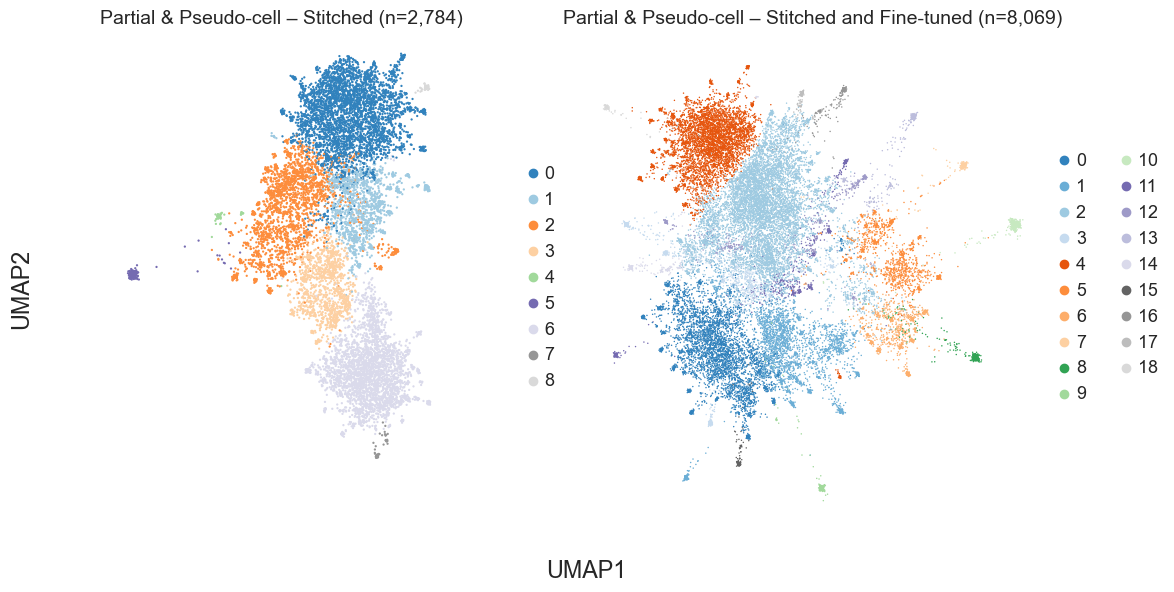

In [121]:
frag_configs = [
    (adata_st_frag_umap, "_leiden", "Partial & Pseudo-cell – Stitched (n=2,784)"),
    (adata_ft_frag_umap, "_leiden", "Partial & Pseudo-cell – Stitched and Fine-tuned (n=8,069)"),
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharex=True,
    sharey=True
)

# Loop through each UMAP and plot on the corresponding axis
for ax, (adata, leiden_col, title) in zip(axes, frag_configs):
    # Ensure the color key exists
    if leiden_col not in adata.obs.columns:
        raise ValueError(f"{leiden_col} not found in adata.obs")
    
    sc.pl.umap(
        adata,
        color=leiden_col,
        palette="tab20c",
        ax=ax,
        show=False,
        title=title
    )
    clean_umap_axes(ax)  # remove axes ticks/spines

# Add common axis labels
fig.supxlabel("UMAP1")
fig.supylabel("UMAP2")

plt.tight_layout()
plt.savefig(
    "plot/lung_cancer_umap_partial_pseudocell.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

## 10. Summary Statistics and Comparisons

In [122]:
# Create summary statistics table
summary_data = []

for adata, name in [
    (adata_st_whole_umap, "Stitched Whole"),
    (adata_st_frag_umap, "Stitched Partial/Pseudocell"),
    (adata_ft_whole_umap, "Fine-tuned Whole"),
    (adata_ft_frag_umap, "Fine-tuned Partial/Pseudocell"),
    (adata_orig_umap, "Original Whole"),
]:
    summary_data.append({
        'Dataset': name,
        'n_cells': adata.shape[0],
        'n_genes': adata.shape[1],
        'mean_transcripts': adata.obs['n_transcripts'].mean(),
        'mean_genes': adata.obs['n_genes'].mean(),
        'mean_purity': adata.obs['cell_purity'].mean(),
        'mean_conflict': adata.obs['conflict_score'].mean(),
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(summary_df.to_string(index=False))
summary_df.to_csv('output/metrics_summary.csv', index=False)
print("\n✓ Saved to output/metrics_summary.csv")


SUMMARY STATISTICS
                      Dataset  n_cells  n_genes  mean_transcripts  mean_genes  mean_purity  mean_conflict
               Stitched Whole    58405      300         20.007380   11.147539     0.355933       0.008670
  Stitched Partial/Pseudocell    11330       93          9.322330    4.191439     0.630598       0.009334
             Fine-tuned Whole    58405      300         18.692492   10.296362     0.372905       0.008495
Fine-tuned Partial/Pseudocell    27148      296          6.719390    4.111647     0.555751       0.006889
               Original Whole    58405      300         24.571150   13.608492     0.291848       0.032136

✓ Saved to output/metrics_summary.csv


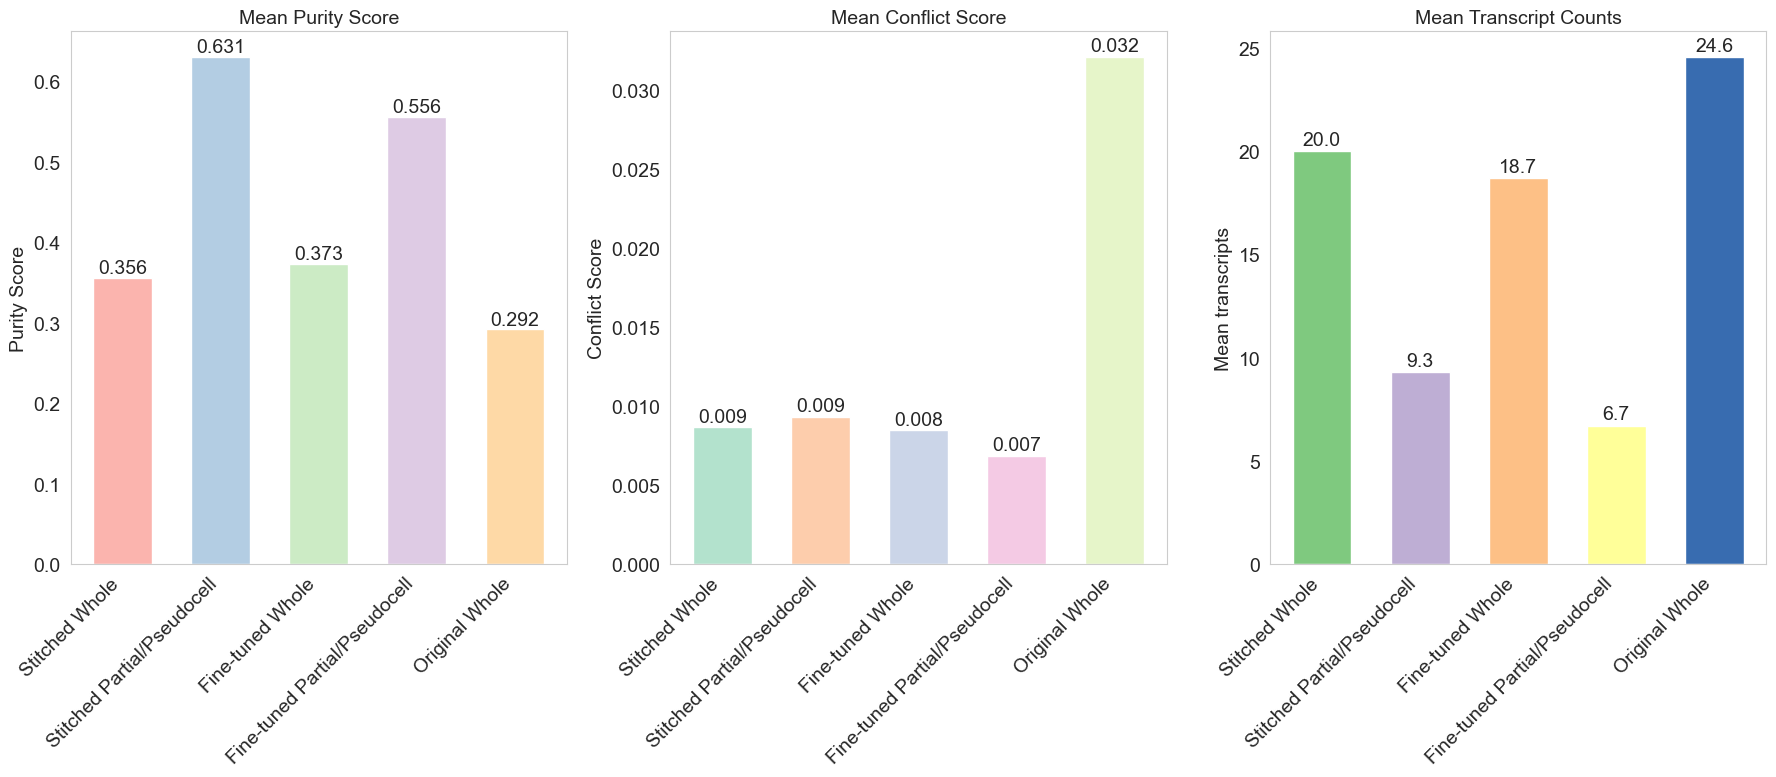

In [128]:
# Use the Dataset column as labels
labels = summary_df['Dataset'].tolist()
x = np.arange(len(labels))
width = 0.6

# Extract the mean values for plotting
purity_scores = summary_df['mean_purity'].values
conflict_scores = summary_df['mean_conflict'].values
transcript_scores = summary_df['mean_transcripts'].values
# 
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# ---------------- PURITY ----------------
bars_purity = axes[0].bar(x, purity_scores, width, color=plt.get_cmap("Pastel1").colors[:len(labels)])
axes[0].grid(False)
axes[0].set_title("Mean Purity Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel("Purity Score")

# Annotate the values on top of bars
for bar in bars_purity:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{height:.3f}', ha='center', va='bottom')

# ---------------- CONFLICT ----------------
bars_conflict = axes[1].bar(x, conflict_scores, width, color=plt.get_cmap("Pastel2").colors[:len(labels)])
axes[1].grid(False)
axes[1].set_title("Mean Conflict Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel("Conflict Score")

# Annotate the values on top of bars
for bar in bars_conflict:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.0001, f'{height:.3f}', ha='center', va='bottom')

# ---------------- MEAN TRANSCRIPTS ----------------
bars_tx = axes[2].bar(x, transcript_scores, width, color=plt.get_cmap("Accent").colors[:len(labels)])
axes[2].grid(False)
axes[2].set_title("Mean Transcript Counts")
axes[2].set_ylabel("Mean transcripts")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right')

for bar in bars_tx:
    height = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.savefig("plot/lung_cancer_mean_purity_conflict_transcript_scores.png", dpi=300)
plt.show()


## 11. Downstream Integration with Scanpy

Visualize cell-type marker genes 

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

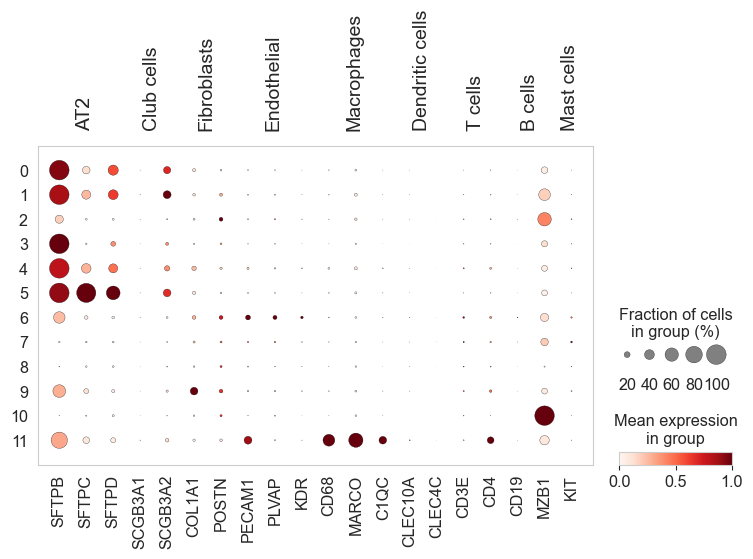

In [124]:
marker_genes = {
    "AT2": ["SFTPB", "SFTPC", "SFTPD"],
    "Club cells": ["SCGB3A1", "SCGB3A2"],
    "Fibroblasts": ["COL1A1", "POSTN"],
    "Endothelial": ["PECAM1", "PLVAP", "KDR"],
    "Macrophages": ["CD68", "MARCO",  "C1QC"],
    "Dendritic cells": ["CLEC10A", "CLEC4C"],
    "T cells": ["CD3E", "CD4"],
    "B cells": ["CD19", "MZB1"],
    "Mast cells": ["KIT"]
}

sc.pl.dotplot(
    adata_orig_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="var",
    dendrogram=False,
    show=False
)

## 12. Notes and Observations

Document any issues found and potential fixes needed.

### Key Observations:

1. **Plotting**: The `sc.pl.dotplot` function does not render the cell type brackets over genes in  `VS Code`. **Using Jypyter Lab for figures.**

2. **Gene Universe Alignment**: Only genes present in the NPMI dataset are retained, which is correct but may reduce the effective cell × gene matrix size. 

### Other Thoughts:

Of note this is a very small biopsy so consider learning NPMI from a bigger tissue or even scRNA-seq and then apply the learned NPMI matrix here.

In [126]:
# Fix data types before saving to h5ad
def prepare_adata_for_saving(adata):
    """Convert problematic data types for h5ad compatibility"""
    # Convert boolean columns properly - fill NaN with False first
    bool_cols = ['cell_purity_bool', 'is_conflict']
    for col in bool_cols:
        if col in adata.obs.columns:
            # Fill NaN values with False, then convert to bool
            adata.obs[col] = adata.obs[col].fillna(False).astype('bool')
    
    # Convert any object-dtype columns to categorical or string
    for col in adata.obs.columns:
        if adata.obs[col].dtype == 'object':
            # Check if it's a string column or categorical
            if adata.obs[col].nunique() < len(adata.obs[col]) * 0.5:
                # If less than 50% unique values, make it categorical
                adata.obs[col] = adata.obs[col].astype('category')
            else:
                # Otherwise keep as string but ensure proper type
                adata.obs[col] = adata.obs[col].astype(str)
    
    return adata

# Save AnnData objects with UMAP
print("Preparing and saving AnnData objects...")

adata_orig_umap = prepare_adata_for_saving(adata_orig_umap)
adata_orig_umap.write("output/adata_orig_umap.h5ad", compression="gzip")
print("✓ Saved adata_orig_umap")

adata_st_whole_umap = prepare_adata_for_saving(adata_st_whole_umap)
adata_st_whole_umap.write("output/adata_st_whole_umap.h5ad", compression="gzip")
print("✓ Saved adata_st_whole_umap")

adata_st_frag_umap = prepare_adata_for_saving(adata_st_frag_umap)
adata_st_frag_umap.write("output/adata_st_frag_umap.h5ad", compression="gzip")
print("✓ Saved adata_st_frag_umap")

adata_ft_whole_umap = prepare_adata_for_saving(adata_ft_whole_umap)
adata_ft_whole_umap.write("output/adata_ft_whole_umap.h5ad", compression="gzip")
print("✓ Saved adata_ft_whole_umap")

adata_ft_frag_umap = prepare_adata_for_saving(adata_ft_frag_umap)
adata_ft_frag_umap.write("output/adata_ft_frag_umap.h5ad", compression="gzip")
print("✓ Saved adata_ft_frag_umap")

print("\n✓ All AnnData objects saved successfully to output/ directory")

Preparing and saving AnnData objects...


/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')


✓ Saved adata_orig_umap


/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')


✓ Saved adata_st_whole_umap


...

✓ Saved adata_st_frag_umap


/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')


✓ Saved adata_ft_whole_umap


/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_32382/4002508613.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs[col] = adata.obs[col].fillna(False).astype('bool')


✓ Saved adata_ft_frag_umap

✓ All AnnData objects saved successfully to output/ directory


## Conclusion

✓ Successfully created AnnData objects for all cell ID versions  
✓ Tested individual metric computation functions  
✓ Identified issue in `sc.pl.dotplot` function implementation in VS Code 
✓ Computed and visualized purity/conflict metrics with UMAP  
✓ Generated summary statistics and comparison plots  
✓ Showcased how the finetuned segmentation enhanced the signal-to-noise ratio

**Next steps**: Move to Jupyter for plotting